# 05 — Drug Normalization Validation

Phase 2D validation: coverage rates, method breakdown, top unmatched names, TA cross-tab, and spot checks.

**Depends on**: `run_normalize_drugs.py` (builds `ref.drug_dictionary` and `norm.study_drugs`)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect("../data/clinical_trials.duckdb", read_only=True)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 50)

## 1. Coverage Summary

In [2]:
total = conn.execute("SELECT COUNT(*) FROM norm.study_drugs").fetchone()[0]
matched = conn.execute("SELECT COUNT(*) FROM norm.study_drugs WHERE canonical_name IS NOT NULL").fetchone()[0]
total_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_drugs").fetchone()[0]
matched_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_drugs WHERE canonical_name IS NOT NULL").fetchone()[0]

print(f"Intervention coverage: {matched:,}/{total:,} ({100*matched/total:.1f}%)")
print(f"Study coverage: {matched_studies:,}/{total_studies:,} ({100*matched_studies/total_studies:.1f}%)")

Intervention coverage: 46,928/82,069 (57.2%)
Study coverage: 24,380/40,508 (60.2%)


In [3]:
breakdown = conn.execute("""
    SELECT mapping_method, COUNT(*) as interventions, COUNT(DISTINCT nct_id) as studies
    FROM norm.study_drugs
    GROUP BY mapping_method
    ORDER BY interventions DESC
""").fetchdf()
breakdown

,mapping_method,interventions,studies
0,unmatched,35141,24890
1,mesh-exact,31624,17183
2,chembl-synonym,8156,6958
3,control-map,7148,6555


In [4]:
dict_stats = conn.execute("""
    SELECT mapping_method, confidence, COUNT(*) as entries
    FROM ref.drug_dictionary
    GROUP BY mapping_method, confidence
    ORDER BY entries DESC
""").fetchdf()
print(f"Drug dictionary: {dict_stats['entries'].sum():,} total entries")
dict_stats

Drug dictionary: 6,180 total entries


,mapping_method,confidence,entries
0,chembl-synonym,high,2473
1,mesh-exact,high,2143
2,control-map,high,1564


## 2. Top Unmatched Drug Names

These are targets for manual curation or V2 normalization (DrugBank, RxNorm).

In [5]:
unmatched = conn.execute("""
    SELECT intervention_name, COUNT(DISTINCT nct_id) as studies
    FROM norm.study_drugs
    WHERE canonical_name IS NULL
    GROUP BY intervention_name
    ORDER BY studies DESC
    LIMIT 30
""").fetchdf()
unmatched

,intervention_name,studies
0,Chemotherapy,198
1,Nab-paclitaxel,120
2,Nab paclitaxel,67
3,SHR-A1811,40
4,BL-B01D1,39
5,Blood sample,31
6,G-CSF,30
7,S-1,30
8,Blood sampling,30
9,PD-1 inhibitor,27


## 3. Most Common Canonical Drugs

In [6]:
top_drugs = conn.execute("""
    SELECT canonical_name, COUNT(DISTINCT nct_id) as studies, mapping_method
    FROM norm.study_drugs
    WHERE canonical_name IS NOT NULL
    GROUP BY canonical_name, mapping_method
    ORDER BY studies DESC
    LIMIT 25
""").fetchdf()
top_drugs

,canonical_name,studies,mapping_method
0,Placebo,5645,control-map
1,pembrolizumab,949,mesh-exact
2,Cyclophosphamide,775,mesh-exact
3,Carboplatin,674,mesh-exact
4,Cisplatin,563,mesh-exact
5,Saline,542,control-map
6,Dexamethasone,537,mesh-exact
7,Paclitaxel,512,mesh-exact
8,Nivolumab,509,mesh-exact
9,Bevacizumab,416,mesh-exact


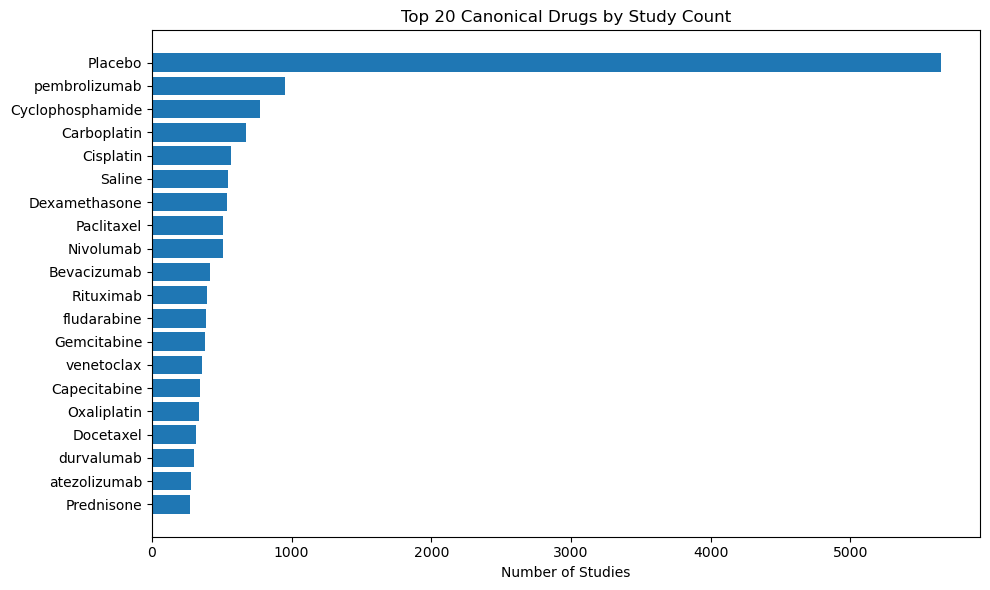

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
top20 = top_drugs.head(20)
ax.barh(top20["canonical_name"], top20["studies"])
ax.set_xlabel("Number of Studies")
ax.set_title("Top 20 Canonical Drugs by Study Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Coverage by Therapeutic Area

In [8]:
ta_cov = conn.execute("""
    SELECT
        ta.therapeutic_area,
        COUNT(DISTINCT sd.nct_id) as drug_studies,
        COUNT(DISTINCT CASE WHEN sd.canonical_name IS NOT NULL THEN sd.nct_id END) as mapped_studies,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN sd.canonical_name IS NOT NULL THEN sd.nct_id END)
              / NULLIF(COUNT(DISTINCT sd.nct_id), 0), 1) as coverage_pct
    FROM norm.study_drugs sd
    INNER JOIN norm.study_therapeutic_areas ta ON sd.nct_id = ta.nct_id
    GROUP BY ta.therapeutic_area
    ORDER BY drug_studies DESC
""").fetchdf()
ta_cov

,therapeutic_area,drug_studies,mapped_studies,coverage_pct
0,Oncology,14910,9262,62.1
1,General/Symptoms,7495,4846,64.7
2,Immunology,5204,3230,62.1
3,Hematology,4752,3019,63.5
4,Gastroenterology,4349,2510,57.7
5,Neurology,4217,2666,63.2
6,Metabolic/Endocrine,3978,2568,64.6
7,Dermatology/Rheumatology,3977,2505,63.0
8,Respiratory,3751,2312,61.6
9,Cardiovascular,3317,2007,60.5


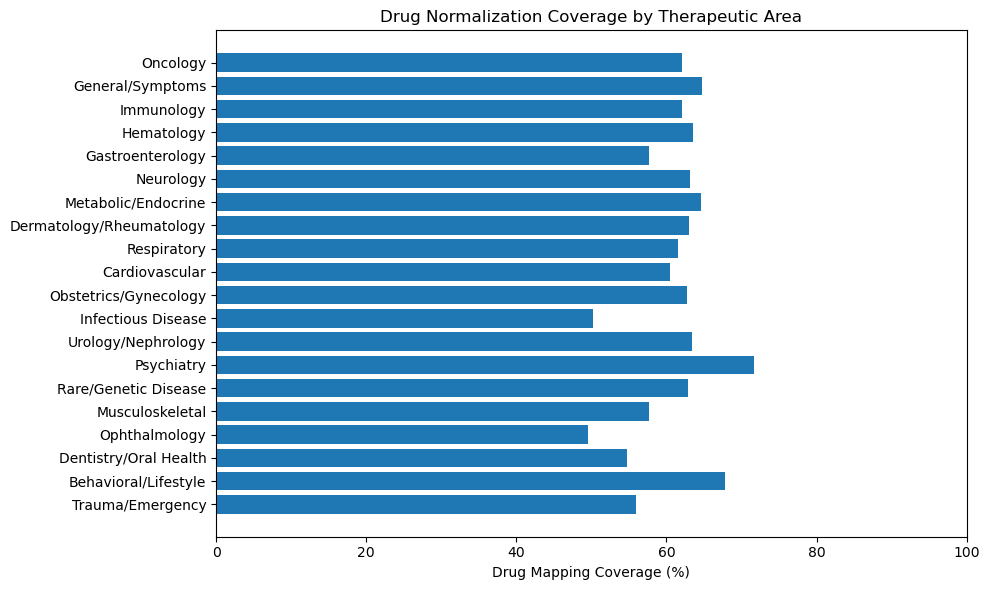

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ta_cov["therapeutic_area"], ta_cov["coverage_pct"])
ax.set_xlabel("Drug Mapping Coverage (%)")
ax.set_title("Drug Normalization Coverage by Therapeutic Area")
ax.set_xlim(0, 100)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Spot Checks

Sample matched entries to verify quality.

In [10]:
print("=== MeSH exact matches (sample) ===")
display(conn.execute("""
    SELECT intervention_name, canonical_name, mapping_method
    FROM norm.study_drugs
    WHERE mapping_method = 'mesh-exact'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== MeSH exact matches (sample) ===


,intervention_name,canonical_name,mapping_method
0,Ethambutol (E),Ethambutol,mesh-exact
1,Epacadostat,epacadostat,mesh-exact
2,Cyclophosphamide,Cyclophosphamide,mesh-exact
3,Furosemide,Furosemide,mesh-exact
4,Olaparib,olaparib,mesh-exact
5,Vedolizumab,vedolizumab,mesh-exact
6,Solriamfetol,solriamfetol,mesh-exact
7,Methotrexate,Methotrexate,mesh-exact
8,Topiramate,Topiramate,mesh-exact
9,Norepinephrine intravenous infusion,Norepinephrine,mesh-exact


In [11]:
print("=== ChEMBL synonym matches (sample) ===")
display(conn.execute("""
    SELECT intervention_name, canonical_name, canonical_id, mapping_method
    FROM norm.study_drugs
    WHERE mapping_method = 'chembl-synonym'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== ChEMBL synonym matches (sample) ===


,intervention_name,canonical_name,canonical_id,mapping_method
0,Vasopressin,VASOPRESSIN,CHEMBL373742,chembl-synonym
1,SPH5030 tablets,SPH-5030,CHEMBL6068562,chembl-synonym
2,Rimegepant,RIMEGEPANT,CHEMBL2178422,chembl-synonym
3,Vincristine Sulfate,VINCRISTINE SULFATE,CHEMBL501867,chembl-synonym
4,Pivmecillinam,AMDINOCILLIN PIVOXIL,CHEMBL1650818,chembl-synonym
5,AB122,ZIMBERELIMAB,CHEMBL4297856,chembl-synonym
6,Enlonstobart,ENLONSTOBART,CHEMBL5315040,chembl-synonym
7,VRC07-523LS 3200mg,VRC07-523LS,CHEMBL4594510,chembl-synonym
8,Ketamine hydrochloride,KETAMINE HYDROCHLORIDE,CHEMBL1714,chembl-synonym
9,Olomorasib,OLOMORASIB,CHEMBL6068410,chembl-synonym


In [12]:
print("=== Control/comparator mappings (sample) ===")
display(conn.execute("""
    SELECT intervention_name, canonical_name, mapping_method
    FROM norm.study_drugs
    WHERE mapping_method = 'control-map'
    ORDER BY random()
    LIMIT 10
""").fetchdf())

=== Control/comparator mappings (sample) ===


,intervention_name,canonical_name,mapping_method
0,Placebo protein powder,Placebo,control-map
1,Placebo,Placebo,control-map
2,Placebo,Placebo,control-map
3,Placebo,Placebo,control-map
4,Placebo,Placebo,control-map
5,placebo,Placebo,control-map
6,matching placebo of emodepside,Placebo,control-map
7,Placebo,Placebo,control-map
8,VV119 Placebo （in adult patients with schizophrenia）,Placebo,control-map
9,Placebo,Placebo,control-map


In [13]:
print("=== Drugs with multiple intervention name variants ===")
display(conn.execute("""
    SELECT canonical_name, COUNT(DISTINCT intervention_name) as variants, 
           STRING_AGG(DISTINCT intervention_name, ' | ' ORDER BY intervention_name) as sample_names
    FROM norm.study_drugs
    WHERE canonical_name IS NOT NULL
    GROUP BY canonical_name
    HAVING COUNT(DISTINCT intervention_name) >= 3
    ORDER BY variants DESC
    LIMIT 15
""").fetchdf())

=== Drugs with multiple intervention name variants ===


,canonical_name,variants,sample_names
0,Placebo,1591,"""Mesalamine"" and ""Placebo"" | 0.00025% Lacripep ophthalmic solution and Place..."
1,Saline,222,0.3mg/kg/min Dimethyltryptamine + Normal Saline infusion | 0.9 % Normal Sali...
2,Standard of Care,126,0.75% MDI-1228_mesylate gel plus Standard of Care | ADT Standard of Care | A...
3,Dexamethasone,37,8mg dexamethasone | DEXAMETHASONE | Dexamethasone | Dexamethasone (0.1 mg/kg...
4,pembrolizumab,34,200 mg Pembrolizumab | PEMBROLIZUMAB (alone or when added to a regimen above...
5,Vehicle,32,BL1332 Vehicle ophthalmic vehicle | BL1332 ophthalmic vehicle | Cream Vehicl...
6,semaglutide,30,Oral Semaglutide | Oral semaglutide | Semaglutide | Semaglutide (1 Mg Dose) ...
7,Control,26,Active Comparator | Active Comparator(NSAIDs-excluded non-opioid or opioid a...
8,Sham Comparator,25,Administration of the sham (PLACEBO) | Ketoconazole 2% Shampoo | PER-001 Int...
9,Aspirin,25,100mg aspirin | 162mg Aspirin | 325 mg Oral Aspirin | 81mg Aspirin | Aspirin...


In [14]:
conn.close()